In [57]:
import importlib 
m = importlib.import_module(".model", "src")
from matplotlib import pyplot as plt
import numpy as np

In [71]:
eta = 0.8    # node retention in edges
gamma = 0.2  # poisson number of nodes from graph
beta = 0.1   # poisson number of novel nodes

In [59]:
timesteps = int(1e6)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta)

In [60]:
C = H.intersection_profile(int(1e7))

In [61]:
C.sum(axis = (0, 1))

array([9.509183e-01, 4.866220e-02, 4.104000e-04, 8.400000e-06,
       6.000000e-07, 1.000000e-07, 0.000000e+00, 0.000000e+00,
       0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00])

[]

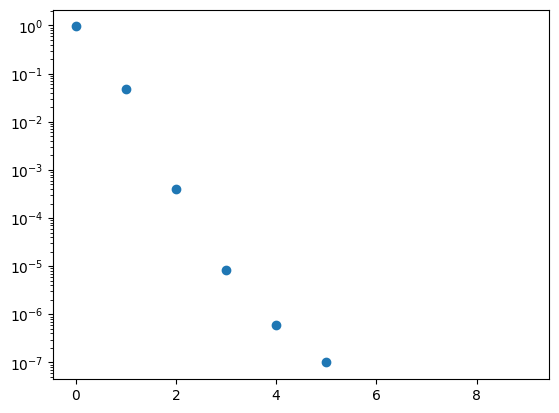

In [62]:
plt.scatter(np.arange(10), C.sum(axis = (0, 1))[0:10])
plt.semilogy()

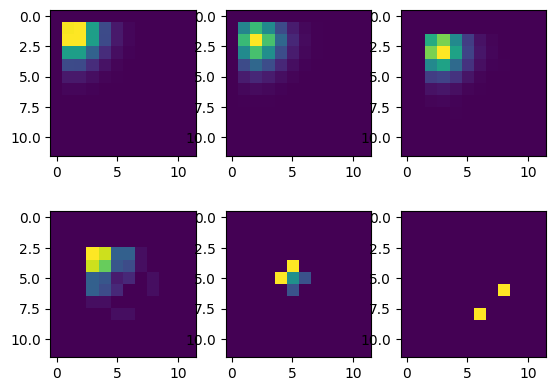

In [63]:
fig, axarr = plt.subplots(2, 3)

for i, ax in enumerate(axarr.ravel()):
    
    ax.imshow(C[:,:,i])

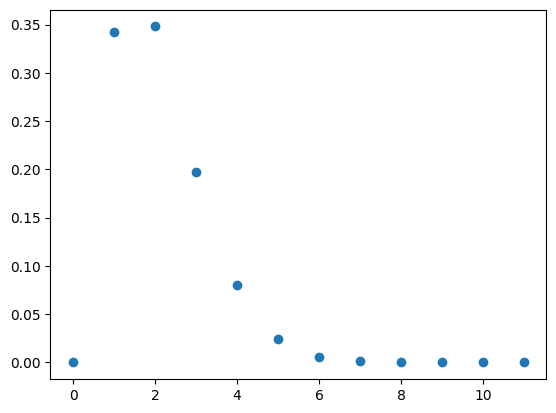

In [66]:
sizes = C.sum(axis = (1, 2))
plt.scatter(np.arange(len(sizes)), sizes)

In [74]:
sizes = H.edge_size_sequence()
sizes.mean(), sizes.var()

(2.1224267551464897, 1.2081102434271938)

In [69]:
pred_m = (beta + gamma)/(1-eta)
prob_0 = (1-eta)
pred_m

1.5000000000000007

In [76]:
len(H.degree_sequence())

106785